# *LompeOSSE* example - Low Earth orbiting satellite constellation (Swarm)

This notebook demonstrates how to apply the *LompOSSE* module in a representative Observation System Simulation Experiment (OSSE). 

*EISCAT 3D will be an international research infrastructure, using radar observations and the incoherent scatter technique for studies of the atmosphere and near-Earth space environment above the Fenno-Scandinavian Arctic.* 

The aim of this OSSE is to evaluate how well global ionospheric electrodynamics can be reconstructed in EISCAT's field of view...

### Imports

In [ ]:
import numpy as np
import pandas as pd
import datetime as dt
import matplotlib as plt
import apexpy
import lompe
from lompe.model.cmodel import Cmodel
from lompe.model.visualization import *
import h5py
import matplotlib.gridspec as gridspec
import secsy as cs
import sys, os
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))  # go one level up from notebook dir
sys.path.append(repo_root)
from lompeosse import LompeOSSE

Path for example data files

In [2]:
lompe_dir = os.path.dirname(os.path.abspath(lompe.__file__))
data_dir = os.path.join(lompe_dir, '../examples/sample_dataset')

### Configure electric field model input

#### Grid
In this example, we define a grid that covers the Fennoscandia region so that the observation geometry corresponds to the EISCAT3D viewing conditions. This grid provides the spatial framework on which the electrodynamics will be reconstructed.




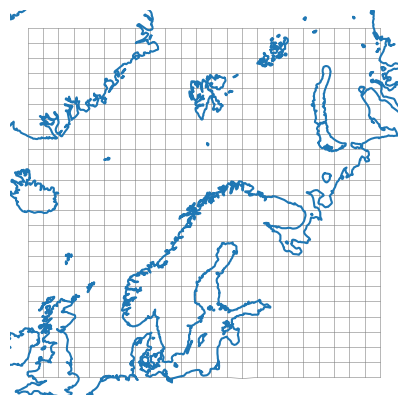

23 x 23 cubed sphere grid
Centered at lon, lat = 20.0, 70.0
Orientation: 1.00 east, 0.00 north, 
Extent: ~27.9 x 27.9 degrees central angle

In [ ]:
# define small grid around satellite trajectory? 

# first define event
# call swarm_orbit_and_grid script 
# then collect the available iridium data (I already have it)
# then normal lompeosse within each frame

# Center of the grid
lonc, latc = 20, 70        # center longitude and latitude
position = (lonc, latc)    # center position
orientation = 0            # orientation angle in degrees (0 = North up)

# Grid dimensions and resolution
L, W, Lres, Wres = 4000e3, 4000e3, 150e3, 150e3 # [m]

# Gamera ionospheric radius
RG = 6500 # [km]

# Construct the cubed sphere grid
grid = lompe.cs.CSgrid(
    lompe.cs.CSprojection(position, orientation),
    L, W, Lres, Wres,
    R=RG * 1e3  # [m]
    )

# Plot grid and coastlines
fig, ax0 = plt.subplots(figsize = (5, 5))
ax0.set_axis_off()
for lon, lat in grid.get_grid_boundaries():
    xi, eta = grid.projection.geo2cube(lon, lat)
    ax0.plot(xi, eta, color = 'grey', linewidth = .4)

xlim, ylim = ax0.get_xlim(), ax0.get_ylim()
for cl in grid.projection.get_projected_coastlines():
    ax0.plot(cl[0], cl[1], color = 'C0')
    
ax0.set_xlim(xlim)
ax0.set_ylim(ylim)
plt.show()

grid

#### Input data
Next, we load the observational datasets that will be used in this OSSE. 

Here, the goal is to see how the available intrumentation around a Swarm satellite can reconstruct the electrodynamics. A specific tool, the Swarm Data Fusion toolbox, exists to collect the contextual data, in space and on ground, in the vicinity of the trajectory of a Swarm satellite. 

Here the goal with be to collect the data around swarm satellite. Then just use all these data to reconstruct the electrodynamics. And then also add a fake electric field dataset along the orbit trajectory to pretend it's Swarm's, and run lompeOSSE again to check if it makes a difference (I guess it should).

the data we want is just iridium around the swarm trajectory. 

We start by defining the event (date of observations).

In [ ]:
datasets2download = ['swarm_E', 'swarm_B', 'supermag', 'superdarn', 'iridium_ampere']
datahandler = DataManager(self.event_date, data_path)
datahandler.fetch_data(datasets2download)

datasets = datahandler.load_data(datasets2download)

data_objects = make_data_objects_for_lompe(datasets, t0, t1)

In [4]:
# Define event date and time interval
event = "2012-04-05"
event_date = event.replace('-', '') # format YYYYMMDD
hour = 1
minute = 19
DT = dt.timedelta(minutes=2) # will select data from stime +- DT 

time = pd.to_datetime(event)
stime = dt.datetime(time.year, time.month, time.day, hour, minute) # specific time to model
t0 = stime - DT
t1 = stime + DT
print('Model interval is ' + str(t0) + ' UT to ' + str(t1) + ' UT')

# Define epoch and initialize Apex object for magnetic coordinate calculations 
epoch = time.year
apx = apexpy.Apex(epoch)


Model interval is 2012-04-05 01:17:00 UT to 2012-04-05 01:21:00 UT


Then we define a dictionnary that contains the paths for the datasets of our choice. These datasets provide complementary information on ionospheric electrodynamics. In this example, we use **SuperMAG** (horizontal ground magnetic field perturbations), **SuperDARN** (line-of-sight plasma convection measurements) and **Iridium/AMPERE** (horizontal magnetic field measurements) data.

Here use: Swarm orbit for a given time interval (use SwarmDF), then create a fake electric field dataset at Swarm coordinates (i.e., pretend Swarm has electric field) and see how that helps the reconstruction

In [5]:
# Dictionary of files
files = {
    "sdarnfn": (f"{event_date}_superdarn_grdmap.h5", "SuperDARN (radar)"),
    "smagfn":  (f"{event_date}_supermag.h5", "SuperMAG (ground magnetometers)"),
    "iridfn":  (f"{event_date}_iridium.h5", "Iridium"),
}

# Build absolute paths and check if files exist
for var, (filename, desc) in files.items():
    path = os.path.join(data_dir, filename)
    # print(path)
    if not os.path.exists(path):
        raise FileNotFoundError(f"Could not find {desc} data file at {path}")
    files[var] = (path, desc)  # overwrite filename with full path

# Load data
superdarn = pd.read_hdf(files["sdarnfn"][0])
supermag  = pd.read_hdf(files["smagfn"][0])
iridium   = pd.read_hdf(files["iridfn"][0])

Next, we filter the full-day datasets for the selected time window (here, ±2 minutes around 01:19 UT on 5 April 2012), and prepare Lompe Data objects. These objects will later be passed to the Lompe **Emodel** object.

For details on how to prepare different data sources for use with Lompe, see for example the notebook: *Data_handling_with_Lompe* (in the lompe/examples/ folder of the Lompe module).

In [6]:
def get_data_subsets(t0, t1):
    """ return subsets of data loaded above, between t0 and t1 """
    
    # SuperDARN data:
    sd = superdarn.loc[(superdarn.index >= t0) & (superdarn.index <= t1) & 
                        (superdarn.vlos < 2000)].dropna()
    sd_vlos = sd['vlos'].values
    sd_coords = np.vstack((sd['glon'].values, sd['glat'].values))
    sd_los  = np.vstack((sd['le'].values, sd['ln'].values))

    # SuperMAG data:
    smag = supermag[supermag.lat <= 90] # select northern hemisphere magnetometers? Necessarry?
    smag = smag[t0 : t1].dropna()
    smag_B = np.vstack((smag.Be.values, smag.Bn.values, smag.Bu.values)) # nT
    smag_coords = np.vstack((smag.lon.values, smag.lat.values))

    # Iridium/AMPERE data
    irid = iridium[(iridium.time >= t0) & (iridium.time <= t1)]

    if not irid.empty:
        irid_B = np.vstack((irid.B_e.values, irid.B_n.values, irid.B_r.values))
        irid_coords = np.vstack(
            (irid.lon.values, irid.lat.values, irid.r.values))
    else:
        irid_B = np.empty((3, 0))
        irid_coords = np.empty((2, 0))

    # Make the data objects (for Lompe)
    superdarn_data = lompe.Data(sd_vlos        , sd_coords  , LOS = sd_los , datatype = 'convection' , iweight = 1.0, error = 50)
    supermag_data  = lompe.Data(smag_B * 1e-9  , smag_coords,                datatype = 'ground_mag' , iweight = 0.0, error = 10e-9)
    iridium_data = lompe.Data(irid_B * 1e-9 if irid_B.size else irid_B, irid_coords, datatype="space_mag_fac", iweight = 1.0, error = 30e-9)
    # note the iweight=0.0 given to SuperMAG data to produce zero weight 
    
    return(superdarn_data, supermag_data, iridium_data)

# Get the data objects for specified time interval
sd_data, sm_data, irid_data = get_data_subsets(t0, t1)


##### Conductance (OK??)

The Lompe technique always requires that **ionospheric conductances** are known. Since the ionospheric conductance is primarily controlled by ionization from solar EUV radiation, here, we use a conductance model derived from SSUSI images.

In [7]:
cmod = Cmodel(grid, event, stime, spline_smoothing = 10, EUV = True, filtersize = 2, how = 'median', 
              param = 'lbhs', tempfile_path = data_dir, basepath = data_dir + '/raw/') #1000

### Generate electric field model 
Now that we have the condutance and datasets, we can set up the Lompe electric field model.

In [8]:
# Create Emodel object
model = lompe.Emodel(grid, (cmod.hall, cmod.pedersen))

# Add data to model
model.add_data(sd_data, sm_data, irid_data) 


### Derive OSSE model

In the previous steps we set up the baseline electric field model. The key feature of *LompeOSSE* is that the inversion for the electric field is performed on **synthetic data**. 

#### Gamera simulation dataset

We begin by loading the synthetic dataset:

In [9]:
# Build path to Gamera data file
repo_root = os.path.abspath(os.path.join(os.getcwd(), "..")) # one level above notebook folder  
datapath = os.path.join(repo_root, "data/Gamera_data.h5")

# Check if data file exists
if not os.path.exists(datapath):
    raise FileNotFoundError(
        f"Required file not found: {datapath}\n"
        "Please download it (https://zenodo.org/records/16882035) and place it in the 'data' folder."
    )

# Open Gamera data file
Gdata = h5py.File(datapath, 'r')

# Print time steps available in Gamera dataset
for key in Gdata.keys():
    print(key)

Step#0
Step#12
Step#13
Step#14
Step#16
Step#19
Step#2
Step#20
Step#21
Step#22
Step#3
X
Y


Select time step of interest (use find-Gamera-snapshot.py to inspect available snapshots):


In [10]:
Gstep = 0 # e.g., if Gstep = 0, the selected time step is Step#0

Optional: Rotate the Gamera snapshot in magnetic local time (hours). This allows exploring multiple OSSE configurations from the same Gamera snapshot

In [11]:
mlt_offset = 0

#### **LompeOSSE** model

Here, we create the *LompeOSSE* model. This is done by replacing the real observational datasets in the baseline electric field model with synthetic data extracted from the selected Gamera snapshot. The grid, dataset types and coordinates are unchanged. 

In [ ]:
lompeosse_obj = LompeOSSE(model, nstep=Gstep, mlt_off=mlt_offset, epoch=epoch)
osse_model = lompeosse_obj.osse_model

Step#0
Hemisphere: NORTH
/Users/margot/Docs/Academia/Research/Python/lompe_osse/data/Gamera_data.h5
dict_keys(['X', 'Y', 'Average energy', 'Density', 'Field-aligned current', 'Hall conductance', 'IM Energy flux', 'IM Energy flux proton', 'IM average energy', 'IM average energy proton', 'Number flux', 'Pedersen conductance', 'Potential', 'Sound speed', 'Zhang average energy', 'Zhang number flux'])

 Initializing OSSE model...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset is empty
Gamera convection data extracted
radius: 6371.2 km
Gamera magnetic field data extracted (ground_mag)
space_mag_full dataset is empty
radius: [7155601.99490493 7155763.81861861 7155929.24047829 7156098.22326661
 7153243.63350678 7153289.01383519 7153339.89193216 7153397.04208464
 7153460.14279373 7153528.58265338 7153603.64166391 7153036.4783142
 7153066.00532243 7153101.30922879 7153142.84666146 7153190.85561281
 7153244.91458858 7153304.88397006 7153634.49150874 7153719

### Run inversion to solve for electrodynamic quantities and visualize results
Finally, we can run the inversion on the LompeOSSE model:

In [13]:
# Run inversion
osse_model.run_inversion(l1 = 1, l2 = 1) # 1) model norm, and 2) gradient of SECS amplitudes (charges) in magnetic eastward direction

ground_mag: Measurement uncertainty effectively changed from 1e-08 to inf


(array([[ 1.60932027e-08,  1.70048858e-08,  1.78216811e-08, ...,
         -5.00958067e-09, -4.62688577e-09, -4.36128595e-09],
        [ 1.70048858e-08,  1.79988955e-08,  1.88896372e-08, ...,
         -5.04495784e-09, -4.63024987e-09, -4.32847266e-09],
        [ 1.78216811e-08,  1.88896372e-08,  1.98524801e-08, ...,
         -5.10221811e-09, -4.64382268e-09, -4.31984695e-09],
        ...,
        [-5.00958067e-09, -5.04495784e-09, -5.10221811e-09, ...,
          1.90972357e-08,  1.71611859e-08,  1.59315270e-08],
        [-4.62688577e-09, -4.63024987e-09, -4.64382268e-09, ...,
          1.71611859e-08,  1.59868349e-08,  1.45156523e-08],
        [-4.36128595e-09, -4.32847266e-09, -4.31984695e-09, ...,
          1.59315270e-08,  1.45156523e-08,  1.42985158e-08]]),
 array([ 1.86530805e-03,  1.94024493e-03,  1.99677827e-03,  2.03320509e-03,
         2.04905111e-03,  2.04476435e-03,  2.02128482e-03,  1.97959479e-03,
         1.92046531e-03,  1.84446505e-03,  1.75227260e-03,  1.64524173e-03,
 

And plot the resulting 2D map of reconstructed ionospheric electrodynamics within the region (grid) defined earlier and using the datasets of our choice: 

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


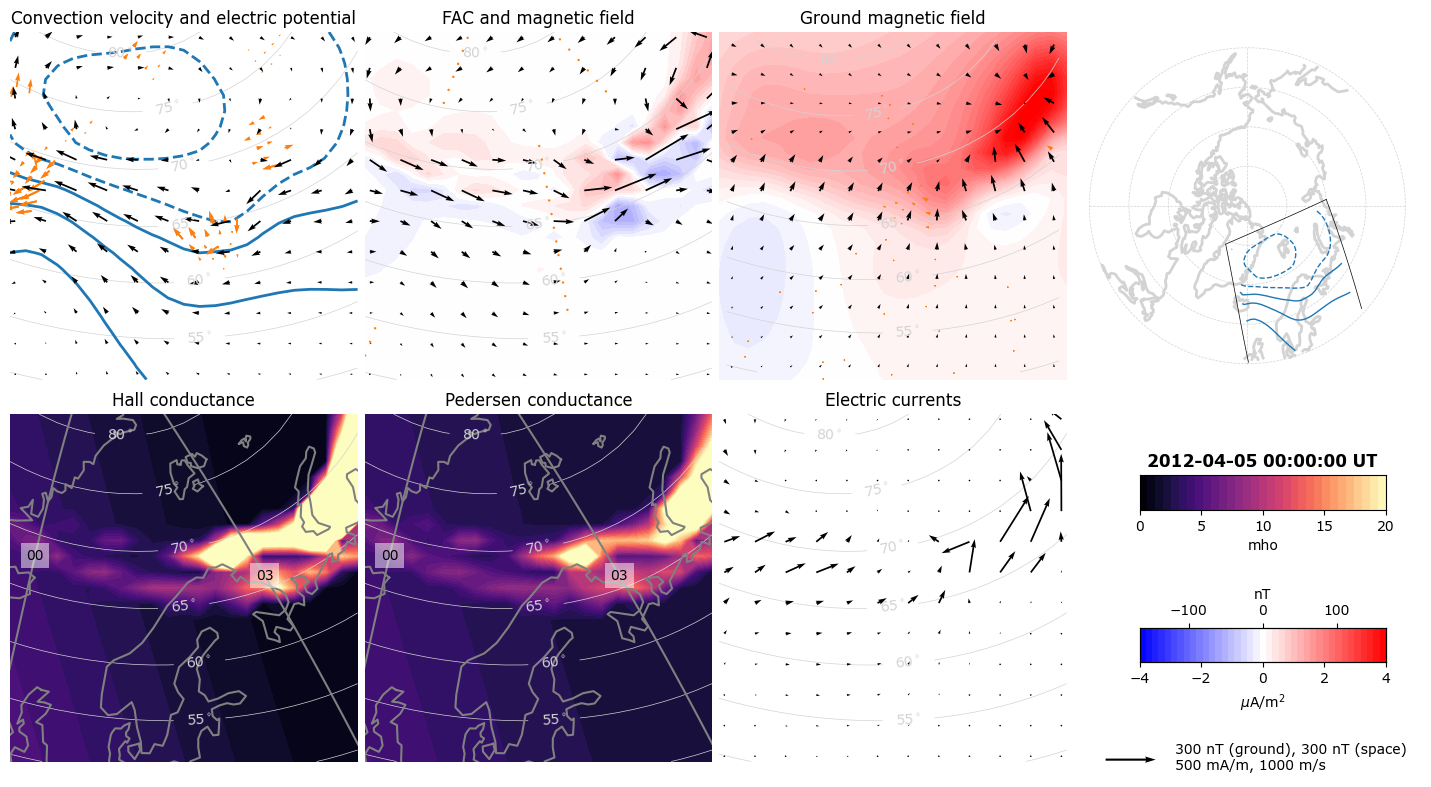

In [14]:
fig = lompe.lompeplot(osse_model, include_data = True, time = time, apex = apx, 
                      colorscales = {'fac'        : np.linspace(-2, 2, 40) * 1e-6 * 2,
                                     'ground_mag' : np.linspace(-500, 500, 50) * 1e-9 / 3, # upward component
                                     'hall'       : np.linspace(0, 20, 32), # mho
                                     'pedersen'   : np.linspace(0, 20, 32)}, # mho
                        quiverscales = {'ground_mag'       : 600*1e-9, 
                                        'space_mag_fac'    : 600*1e-9, 
                                        'space_mag_full'   : 600*1e-9, 
                                        'electric_current' : 1}) # 1000*1e-3
plt.show()

The top row shows, from left to right (input data is shown in orange): 
- Convection flow field and electric potential contours
- horizontal magnetic field disturbances 110 km above the ionosphere as black arrows and radial current density as color contours
- horizontal ground magnetic field perturbations as black arrows and radial magnetic field perturbations as color contours
- a map that shows the grid’s position and orientation with respect to apex magnetic latitude and local time.

The bottom row shows, from left to right: 
- Pedersen conductance
- Hall conductance
- horizontal height-integrated ionospheric currents based on Lompe output
- color scale / vector scales

## Validate the OSSE setup

Finally, we can validate our synthetic model against Gamera "truth". 



First, we extract the electrodynamics quantities of our choice from the LompeOSSE model:


In [15]:
# LompeOSSE-reconstructed quantities
potOSSE = osse_model.E_pot(lon=grid.lon, lat=grid.lat) * 1e-3 # V
potOSSE = potOSSE.reshape(grid.lon.shape)

facOSSE = osse_model.FAC(lon=grid.lon, lat=grid.lat)
facOSSE = facOSSE.reshape(grid.lon.shape)

Then we extract the same electrodynamics quantities from the Gamera simulation dataset, and interpolate them to the user-defined grid (grid used to derive the LompeOSSE model):

In [ ]:
hemisphere = 'NORTH' if latc > 0 else 'SOUTH'

# Extract electric potential and field-aligned currents from Gamera dataset
potG = Gdata[f'Step#{Gstep}']['Potential ' +hemisphere][:]
facG = Gdata[f'Step#{Gstep}']['Field-aligned current ' +hemisphere][:]

# Interpolate to LompeOSSE grid
interp_potG = lompeosse_obj.interp2lompegrid(potG)
interp_facG = lompeosse_obj.interp2lompegrid(facG)

Finally, plot both quantities next to each other:

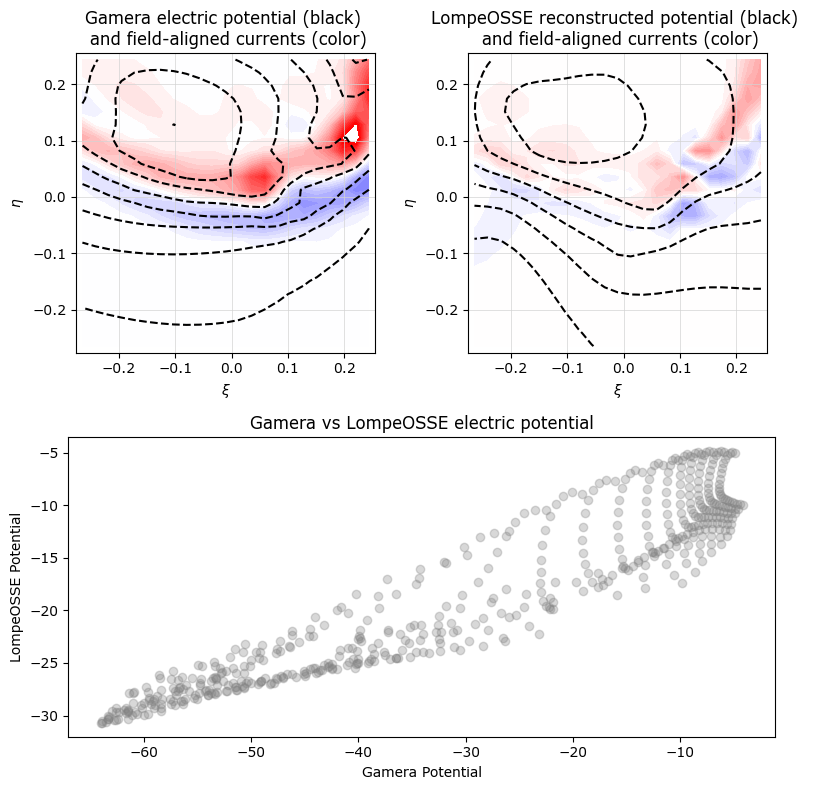

In [ ]:
fac_levels = np.linspace(-1.95, 1.95, 40) * 1e-6 * 2

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# First panel (top-left): Gamera quantities
ax1 = fig.add_subplot(gs[0, 0])  
csax1 = cs.CSplot(ax1, grid, gridtype='cs')
csax1.contour(grid.lon, grid.lat, interp_potG, colors='k')
csax1.contourf(grid.lon, grid.lat, interp_facG*(-1), cmap='bwr', levels=fac_levels*1e6)
ax1.set_title("Gamera electric potential (black) \n and field-aligned currents (color)")

# Second panel (top-right): LompeOSSE-reconstructed quantities
ax2 = fig.add_subplot(gs[0, 1])  
csax2 = cs.CSplot(ax2, grid, gridtype='cs')
csax2.contour(grid.lon, grid.lat, potOSSE, colors='k')
csax2.contourf(grid.lon, grid.lat, facOSSE, cmap='bwr', levels=fac_levels)
ax2.set_title("LompeOSSE reconstructed potential (black) \n and field-aligned currents (color)")

# Third panel (bottom): Scatter plot Gamera VS Lompe-reconstructed potential (should be a line ish)
ax3 = fig.add_subplot(gs[1, :])
ax3.scatter(interp_potG, potOSSE, alpha=.3, color='grey')
ax3.set_xlabel("Gamera Potential")
ax3.set_ylabel("LompeOSSE Potential")
ax3.set_title("Gamera vs LompeOSSE electric potential")
# plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

We can also compute the correlation coefficient between Gamera truth and LompeOSSE-reconstructed quantity (here, the electric potential):

In [18]:
corr_coef = np.corrcoef(interp_potG.flatten(), potOSSE.flatten())[0, 1]
print(f"Correlation coefficient (Gamera vs LompeOSSE potential): \n {corr_coef:.3f}")

Correlation coefficient (Gamera vs LompeOSSE potential): 
 0.937


## Optional

Here, we repeat the same experiment but introduce a small modification to the input datasets. By adding artificial magnetic field measurements from an additional station located in a region where the original Lompe solution appeared under-resolved or overly smooth, we can examine whether the solution becomes more structured.

We begin by constructing a new dataset that includes our additional (fake) ground magnetometer stations. Only the station coordinates matter at this stage; the magnetic field values assigned here are placeholders. They will later be overwritten with synthetic measurements produced by LompeOSSE.

In [ ]:
# Fake coordinates: repeat the station lon/lat for each time step (e.g., 5 times)
# fake_lon = np.full(5, 55.0)
# fake_lat = np.full(5, 74.0) # greenland
# fake_coords = np.vstack((fake_lon, fake_lat))

# # Fake B components
# fake_B = np.vstack([
#     np.full(5, 100),  # Be
#     np.full(5, 50),   # Bn
#     np.full(5, -20)   # Bu
# ])

rep= 5

lons = np.repeat([-11.0, -11.0, -11.0], rep)     # 3 stations
lats = np.repeat([65.0, 62.5, 60.0], rep)
fake_coords = np.vstack((lons, lats))

Be = np.repeat([100, 80,  60], rep)
Bn = np.repeat([50,  40,  30], rep)
Bu = np.repeat([-20, -10, -5], rep)

fake_B = np.vstack((Be, Bn, Bu))

# Create Lompe Data object
fake_groundmag_data  = lompe.Data(fake_B * 1e-9, fake_coords, datatype = 'ground_mag' , iweight = 0.0, error = 10e-9)


We will then add this data to the electric field model defined earlier. 
Since the model object was created earlier, there is no need to define a new one. We can simply replace the input data after using *clear_model()*. Here, the input data is the same as before, plus the new magnetometer data. 

In [ ]:
# Clear model and pass conductances
model.clear_model(Hall_Pedersen_conductance=(cmod.hall, cmod.pedersen))

# Add data to model
model.add_data(sd_data, sm_data, irid_data, fake_groundmag_data)

We can then create the corresponding synthetic model using LompeOSSE:

In [47]:
lompeosse_obj = LompeOSSE(model, nstep=Gstep, mlt_off=mlt_offset, epoch=epoch)
osse_model = lompeosse_obj.osse_model

Step#0
Hemisphere: NORTH
/Users/margot/Docs/Academia/Research/Python/lompe_osse/data/Gamera_data.h5
dict_keys(['X', 'Y', 'Average energy', 'Density', 'Field-aligned current', 'Hall conductance', 'IM Energy flux', 'IM Energy flux proton', 'IM average energy', 'IM average energy proton', 'Number flux', 'Pedersen conductance', 'Potential', 'Sound speed', 'Zhang average energy', 'Zhang number flux'])

 Initializing OSSE model...

 Scanning user datasets and searching for corresponding Gamera data...
efield dataset is empty
Gamera convection data extracted
radius: 6371.2 km
Gamera magnetic field data extracted (ground_mag)
radius: 6371.2 km
Gamera magnetic field data extracted (ground_mag)
space_mag_full dataset is empty
radius: [7155601.99490493 7155763.81861861 7155929.24047829 7156098.22326661
 7153243.63350678 7153289.01383519 7153339.89193216 7153397.04208464
 7153460.14279373 7153528.58265338 7153603.64166391 7153036.4783142
 7153066.00532243 7153101.30922879 7153142.84666146 7153190.

And finally run the inversion and plot the results:

ground_mag: Measurement uncertainty effectively changed from 1e-08 to inf
ground_mag: Measurement uncertainty effectively changed from 1e-08 to inf


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


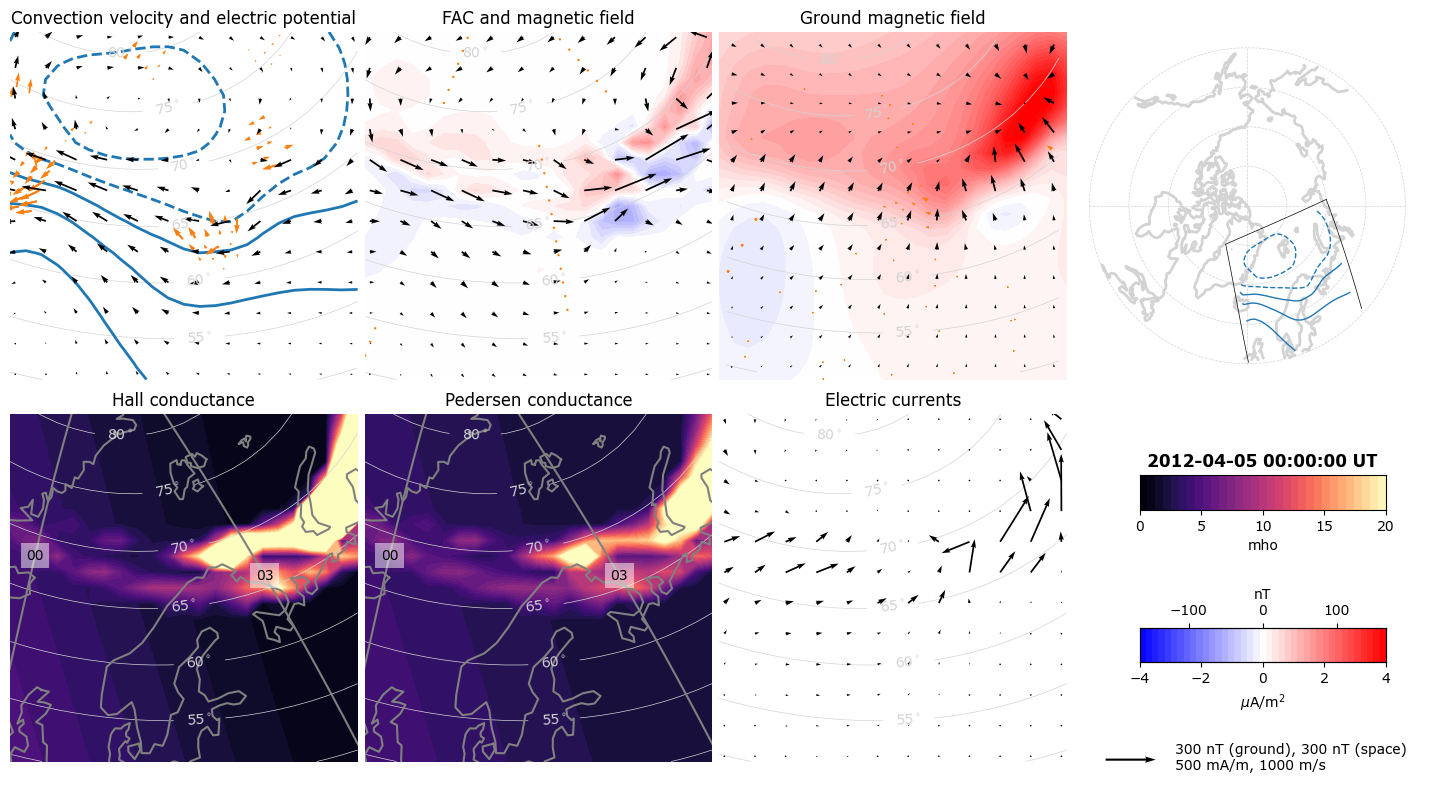

In [48]:
# Run inversion
osse_model.run_inversion(l1 = 1, l2 = 1) # 1) model norm, and 2) gradient of SECS amplitudes (charges) in magnetic eastward direction

# Plot
fig = lompe.lompeplot(osse_model, include_data = True, time = time, apex = apx, 
                      colorscales = {'fac'        : np.linspace(-2, 2, 40) * 1e-6 * 2,
                                     'ground_mag' : np.linspace(-500, 500, 50) * 1e-9 / 3, # upward component
                                     'hall'       : np.linspace(0, 20, 32), # mho
                                     'pedersen'   : np.linspace(0, 20, 32)}, # mho
                        quiverscales = {'ground_mag'       : 600*1e-9, 
                                        'space_mag_fac'    : 600*1e-9, 
                                        'space_mag_full'   : 600*1e-9, 
                                        'electric_current' : 1}) # 1000*1e-3
plt.show()

Now this last plot can be compared with the previous Lompe output. We are trying to see if the solution is changed, i.e., if adding a new magnetometer has led to any major differences in the reconstruction of the ionospheric electrodynamics in EISCAT 3D field of view. Is it improved? (WHY IS THERE NO DIFFERENCE?)


See how the model output changes when varying the different sources of input data by comparing the first output to that one. 

Here, the point is to demonstrate that adding a new magnetometer at this specific location would improve the reconstruction of the ionospheric electrodynamics in EISCAT field of view... (how well the Lompe technique can reconstruct the Gamera truth)

This OSSE is trying to answer the following question: how well can we reconstruct the electrodynamics with SuperDARN, SuperMAG and Iridium, knowing the conductance. 

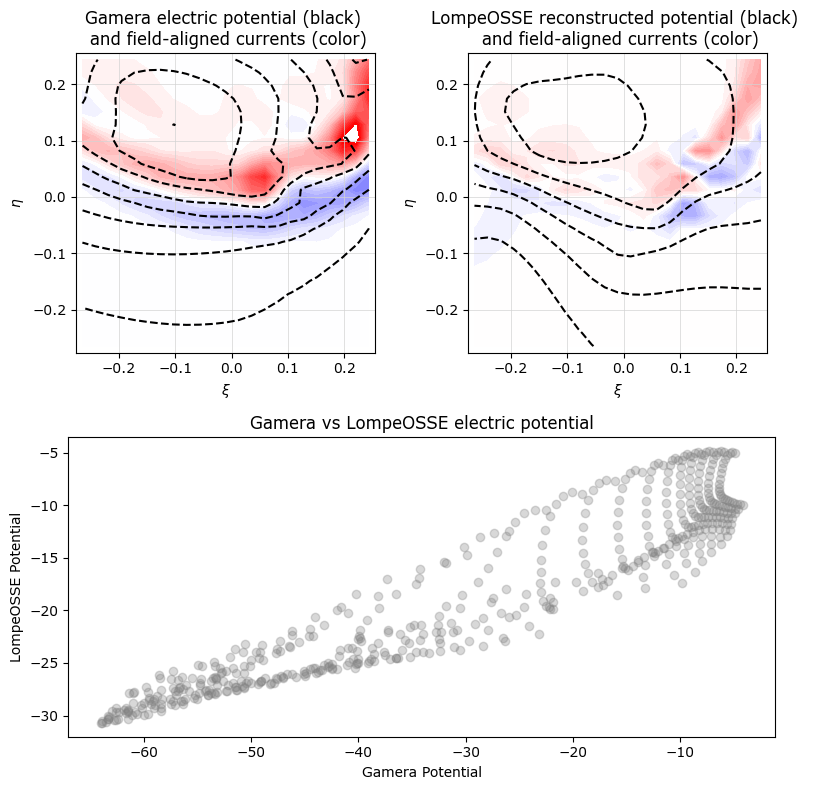

In [49]:
# LompeOSSE-reconstructed quantities
potOSSE = osse_model.E_pot(lon=grid.lon, lat=grid.lat) * 1e-3 # V
potOSSE = potOSSE.reshape(grid.lon.shape)

facOSSE = osse_model.FAC(lon=grid.lon, lat=grid.lat)
facOSSE = facOSSE.reshape(grid.lon.shape)

# Extract electric potential and field-aligned currents from Gamera dataset
potG = Gdata[f'Step#{Gstep}']['Potential ' +hemisphere][:]
facG = Gdata[f'Step#{Gstep}']['Field-aligned current ' +hemisphere][:]

# Interpolate to LompeOSSE grid
interp_potG = lompeosse_obj.interp2lompegrid(potG)
interp_facG = lompeosse_obj.interp2lompegrid(facG)

fac_levels = np.linspace(-1.95, 1.95, 40) * 1e-6 * 2

fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1])

# First panel (top-left): Gamera quantities
ax1 = fig.add_subplot(gs[0, 0])  
csax1 = cs.CSplot(ax1, grid, gridtype='cs')
csax1.contour(grid.lon, grid.lat, interp_potG, colors='k')
csax1.contourf(grid.lon, grid.lat, interp_facG*(-1), cmap='bwr', levels=fac_levels*1e6)
ax1.set_title("Gamera electric potential (black) \n and field-aligned currents (color)")

# Second panel (top-right): LompeOSSE-reconstructed quantities
ax2 = fig.add_subplot(gs[0, 1])  
csax2 = cs.CSplot(ax2, grid, gridtype='cs')
csax2.contour(grid.lon, grid.lat, potOSSE, colors='k')
csax2.contourf(grid.lon, grid.lat, facOSSE, cmap='bwr', levels=fac_levels)
ax2.set_title("LompeOSSE reconstructed potential (black) \n and field-aligned currents (color)")

# Third panel (bottom): Scatter plot Gamera VS Lompe-reconstructed potential (should be a line ish)
ax3 = fig.add_subplot(gs[1, :])
ax3.scatter(interp_potG, potOSSE, alpha=.3, color='grey')
ax3.set_xlabel("Gamera Potential")
ax3.set_ylabel("LompeOSSE Potential")
ax3.set_title("Gamera vs LompeOSSE electric potential")
# plt.gca().set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [26]:
corr_coef = np.corrcoef(interp_potG.flatten(), potOSSE.flatten())[0, 1]
print(f"Correlation coefficient (Gamera vs LompeOSSE potential): \n {corr_coef:.3f}")

Correlation coefficient (Gamera vs LompeOSSE potential): 
 0.937
